## 1. Forecasting Problem Definition

The selected dataset is a univariate time series sampled every 5 hours.

The forecasting target is the future value of the signal:

\[
y_t = \text{signal value at time } t
\]

The model will use information available up to the prediction time to estimate future signal values. No future observations will be used as inputs.

The final model must generate forecasts for at least 6 months beyond the end of the historical data.

Because the objective is future forecasting, model validation will use a chronological train-validation split rather than a random split. The validation period will simulate forecasting on observations that occur after the training period.

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "timeseries_5h.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["datetime"])

df = (
    df[["datetime", "value"]]
    .sort_values("datetime")
    .reset_index(drop=True)
)

FORECAST_END = df["datetime"].max() + pd.DateOffset(months=6)

FORECAST_HORIZON_STEPS = (
    (FORECAST_END - df["datetime"].max()).total_seconds()
    / (SAMPLING_HOURS * 3600)
)

FORECAST_HORIZON_STEPS = int(np.ceil(FORECAST_HORIZON_STEPS))

print("Forecast end:", FORECAST_END)
print("Forecast horizon:", FORECAST_HORIZON_STEPS, "steps")

print("Observations:", len(df))
print("Sampling interval:", SAMPLING_HOURS, "hours")
print("Historical period:", df["datetime"].min(), "to", df["datetime"].max())
print("6-month horizon:", FORECAST_HORIZON_STEPS, "steps")

Forecast end: 2018-06-30 20:00:00
Forecast horizon: 869 steps
Observations: 3509
Sampling interval: 5 hours
Historical period: 2016-01-01 00:00:00 to 2017-12-31 20:00:00
6-month horizon: 869 steps


## 2. Chronological Train-Validation Split

Since the final objective is long-horizon forecasting, the validation setup should mimic the real forecasting task.

The last **6 calendar months** of the historical data are held out as validation data, while all earlier observations are used for training.

This preserves the temporal order of the series and ensures that the model is evaluated only on observations that occur after the training period.

The 6-month validation horizon is also aligned with the minimum forecast horizon required by the assignment.

In [7]:
# Use the last 6 calendar months as the validation period

validation_start = df["datetime"].max() - pd.DateOffset(months=6)

train = df[df["datetime"] < validation_start].copy()
validation = df[df["datetime"] >= validation_start].copy()

print("Training:")
print("  Start:", train["datetime"].min())
print("  End:", train["datetime"].max())
print("  Observations:", len(train))

print("\nValidation:")
print("  Start:", validation["datetime"].min())
print("  End:", validation["datetime"].max())
print("  Observations:", len(validation))

print("\nValidation duration:",
      validation["datetime"].max() - validation["datetime"].min())

Training:
  Start: 2016-01-01 00:00:00
  End: 2017-06-30 16:00:00
  Observations: 2625

Validation:
  Start: 2017-06-30 21:00:00
  End: 2017-12-31 20:00:00
  Observations: 884

Validation duration: 183 days 23:00:00


## 3. Target and Feature Strategy

The forecasting target is the signal value at each future timestamp:
$$
y_t = \text{value}_t
$$

The dataset contains only one observed variable, so there are no external explanatory variables.

The exploratory analysis identified a strong recurring period of approximately **274 hours (11.42 days)**. Since the final forecast extends 6 months into the future, the feature representation should allow the model to extrapolate this periodic structure rather than relying only on short-term lagged observations.

Therefore, the forecasting experiments will compare simple baselines with models using time and periodic features derived from the historical timestamps.

The validation data will remain completely unseen when fitting the models and estimating model parameters.

## 4. Baseline Forecasts

Before introducing engineered features or machine-learning models, simple forecasting baselines are established.

### Naive baseline

The naive model predicts every future value using the last observed training value. This provides a basic reference level for forecasting performance.

### Seasonal naive baseline

Exploratory analysis identified a dominant period of approximately 274 hours. With a 5-hour sampling interval, this corresponds to approximately 55 observations per cycle.

The seasonal naive model therefore predicts each future value using the observation approximately one dominant cycle earlier:

\[
\hat{y}_t = y_{t-55}
\]

These baselines provide reference points against which more sophisticated forecasting approaches can be evaluated.

In [9]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error


# --------------------------------------------------
# Baseline configuration
# --------------------------------------------------

SEASONAL_LAG = 55


# --------------------------------------------------
# Actual validation values
# --------------------------------------------------

actual = validation["value"].to_numpy()


# --------------------------------------------------
# 1. Naive baseline
# --------------------------------------------------
# Predict every validation value using the
# last value observed in the training data.

last_train_value = train["value"].iloc[-1]

naive_forecast = np.full(
    len(validation),
    last_train_value
)


# --------------------------------------------------
# 2. Seasonal naive baseline
# --------------------------------------------------
# The dominant period is approximately:
#
# 274 hours / 5 hours ≈ 54.8 observations
#
# Therefore, we use 55 observations as one cycle.
#
# Take the final 55 observations from training
# and repeat this pattern across the entire
# validation horizon.

seasonal_pattern = train["value"].to_numpy()[-SEASONAL_LAG:]

seasonal_forecast = np.tile(
    seasonal_pattern,
    int(np.ceil(len(validation) / SEASONAL_LAG))
)[:len(validation)]


# --------------------------------------------------
# 3. Evaluation function
# --------------------------------------------------

def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    return mae, rmse


# --------------------------------------------------
# 4. Calculate baseline performance
# --------------------------------------------------

naive_mae, naive_rmse = calculate_metrics(
    actual,
    naive_forecast
)

seasonal_mae, seasonal_rmse = calculate_metrics(
    actual,
    seasonal_forecast
)


# --------------------------------------------------
# 5. Create comparison table
# --------------------------------------------------

baseline_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive (55)"
    ],
    "MAE": [
        naive_mae,
        seasonal_mae
    ],
    "RMSE": [
        naive_rmse,
        seasonal_rmse
    ]
})


baseline_results = baseline_results.round(4)

display(baseline_results)

,Model,MAE,RMSE
0,Naive,2.8456,3.1884
1,Seasonal Naive (55),1.8029,2.1570


## 5. Baseline Forecast Visualization

The seasonal-naive baseline performs substantially better than the naive baseline, indicating that the detected periodic structure contains useful predictive information.

We now visualize the validation period together with both baseline forecasts. This helps assess whether the seasonal baseline captures the shape and timing of the recurring signal and where systematic errors remain.

The validation observations are used only for evaluation and visualization; they are not used to construct the forecasts.

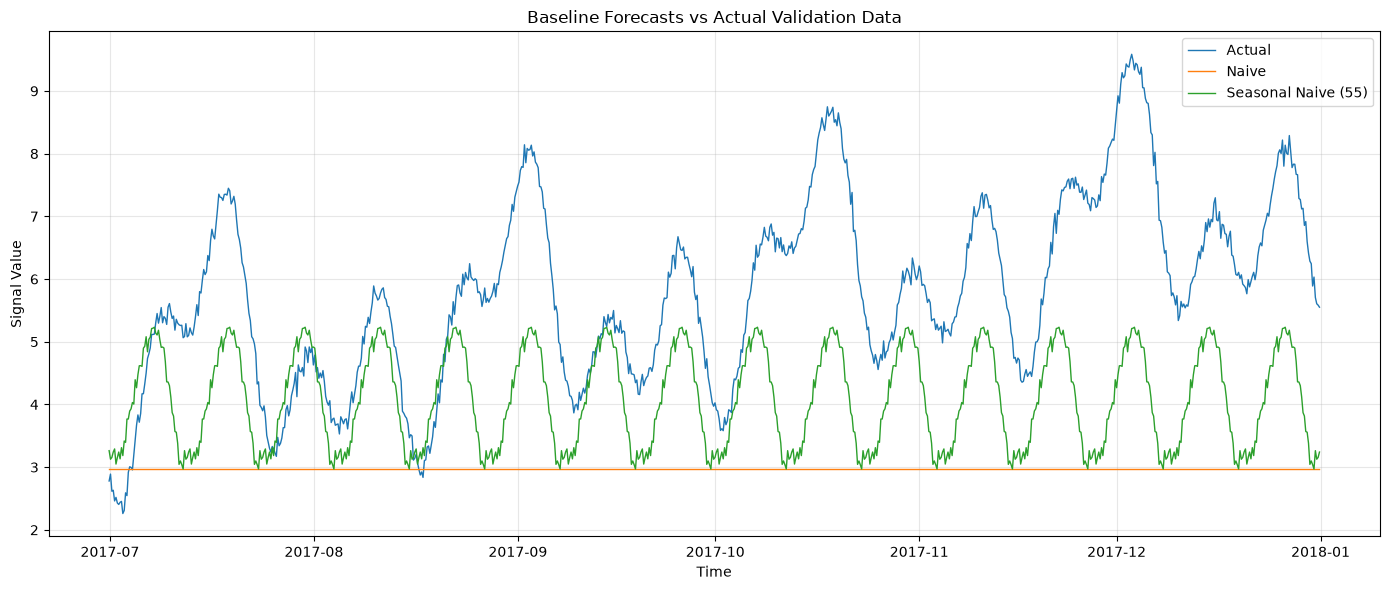

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    validation["datetime"],
    actual,
    label="Actual",
    linewidth=1
)

plt.plot(
    validation["datetime"],
    naive_forecast,
    label="Naive",
    linewidth=1
)

plt.plot(
    validation["datetime"],
    seasonal_forecast,
    label="Seasonal Naive (55)",
    linewidth=1
)

plt.title("Baseline Forecasts vs Actual Validation Data")
plt.xlabel("Time")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Periodic and Trend Features

The exploratory analysis showed two important characteristics of the signal:

1. The overall signal level changes over time.
2. The signal contains a strong recurring component with a period of approximately 274.12 hours.

We therefore construct features representing these two components.

### Time feature

A sequential `time_index` is used to represent the passage of time. This allows the model to learn a systematic change in the signal level over the historical period.

### Periodic features

The dominant period identified through FFT was approximately 274.12 hours.

For a 5-hour sampling interval, this corresponds to approximately:

$$
P_{\text{steps}} = \frac{274.12}{5} \approx 54.82
$$

The position within this cycle is represented using sine and cosine:

$$
\sin\left(\frac{2\pi t}{P_{\text{steps}}}\right)
$$

$$
\cos\left(\frac{2\pi t}{P_{\text{steps}}}\right)
$$

Using both sine and cosine provides a smooth representation of the repeating cycle without creating a discontinuity between the end and beginning of the cycle.

These features are constructed from time only, so they can also be calculated for future timestamps where the signal value is unknown.

In [11]:
# Dominant period identified during Notebook 1
DOMINANT_PERIOD_HOURS = 274.12

# Convert the period from hours to 5-hour observations
DOMINANT_PERIOD_STEPS = (
    DOMINANT_PERIOD_HOURS / SAMPLING_HOURS
)

print("Dominant period (hours):", DOMINANT_PERIOD_HOURS)
print("Dominant period (steps):", DOMINANT_PERIOD_STEPS)


def create_features(dataframe):
    features = dataframe[["datetime", "value"]].copy()

    # Sequential time index
    features["time_index"] = np.arange(len(features))

    # Position within the discovered cycle
    cycle_angle = (
        2 * np.pi * features["time_index"]
        / DOMINANT_PERIOD_STEPS
    )

    features["sin_cycle"] = np.sin(cycle_angle)
    features["cos_cycle"] = np.cos(cycle_angle)

    return features


feature_data = create_features(df)

display(feature_data.head(10))

Dominant period (hours): 274.12
Dominant period (steps): 54.824


,datetime,value,time_index,sin_cycle,cos_cycle
0,2016-01-01 00:00:00,0.140965,0,0.000000,1.000000
1,2016-01-01 05:00:00,-0.014609,1,0.114356,0.993440
2,2016-01-01 10:00:00,0.325199,2,0.227211,0.973846
3,2016-01-01 15:00:00,0.504311,3,0.337085,0.941474
4,2016-01-01 20:00:00,0.545418,4,0.442537,0.896750
5,2016-01-02 01:00:00,0.674843,5,0.542183,0.840261
6,2016-01-02 06:00:00,0.900984,6,0.634714,0.772747
7,2016-01-02 11:00:00,0.937778,7,0.718919,0.695094
8,2016-01-02 16:00:00,0.995823,8,0.793690,0.608322
9,2016-01-02 21:00:00,1.175420,9,0.858049,0.513568


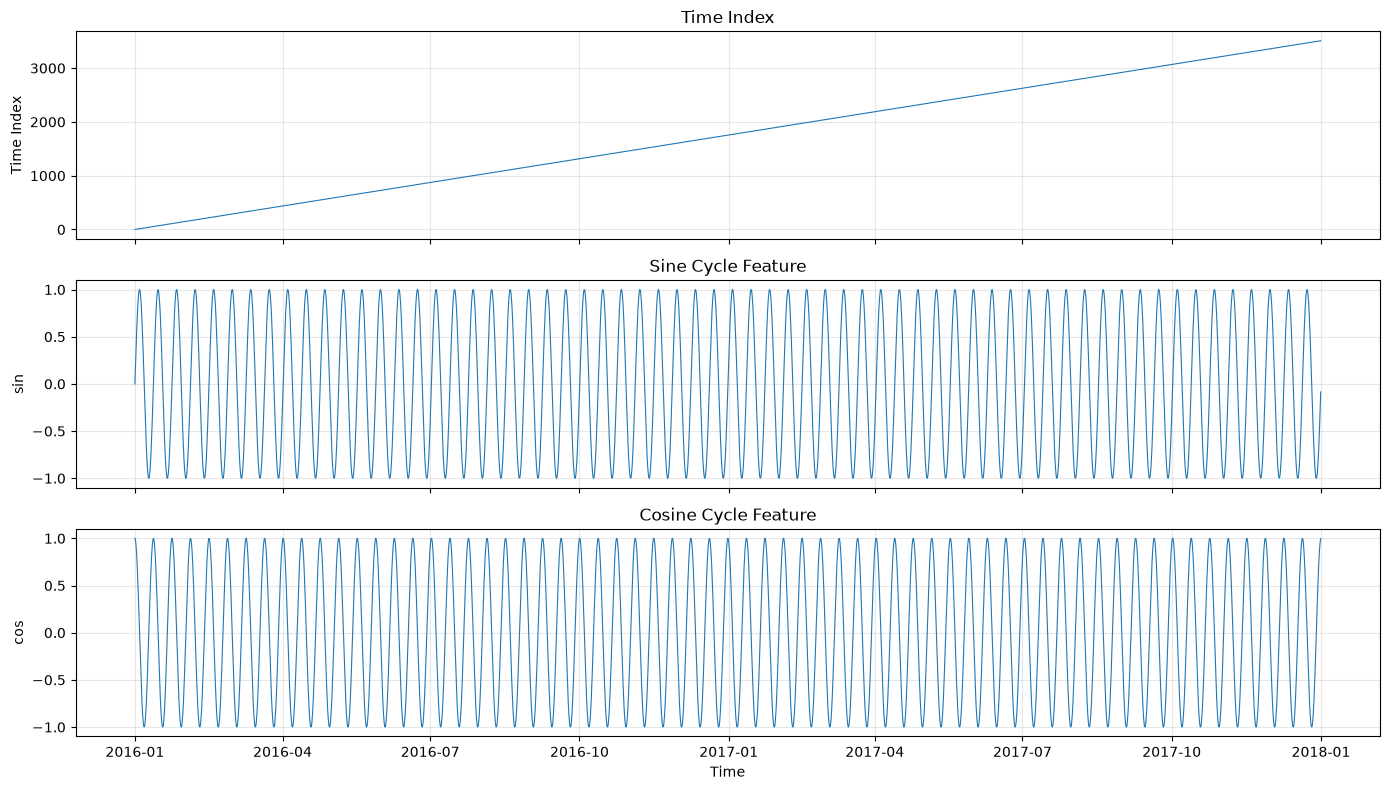

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    feature_data["datetime"],
    feature_data["time_index"],
    linewidth=0.8
)
axes[0].set_title("Time Index")
axes[0].set_ylabel("Time Index")
axes[0].grid(alpha=0.3)

axes[1].plot(
    feature_data["datetime"],
    feature_data["sin_cycle"],
    linewidth=0.8
)
axes[1].set_title("Sine Cycle Feature")
axes[1].set_ylabel("sin")
axes[1].grid(alpha=0.3)

axes[2].plot(
    feature_data["datetime"],
    feature_data["cos_cycle"],
    linewidth=0.8
)
axes[2].set_title("Cosine Cycle Feature")
axes[2].set_ylabel("cos")
axes[2].set_xlabel("Time")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. First Feature-Based Model: Linear Regression

The first feature-based model uses a simple linear regression.

The model receives three inputs:

- `time_index` to represent the changing overall level of the signal.
- `sin_cycle` to represent the periodic component.
- `cos_cycle` to represent the periodic component.

The model therefore has the form:

$$
\hat{y}_t =
\beta_0
+
\beta_1 t
+
\beta_2 \sin\left(\frac{2\pi t}{P}\right)
+
\beta_3 \cos\left(\frac{2\pi t}{P}\right)
$$

where $P$ is the dominant period measured from the data.

The model is fitted only on the training period. The validation period remains unseen and is used only to evaluate forecasting performance.

The purpose of this experiment is to test whether the two main structures identified during exploration — trend and periodicity — are sufficient to produce a useful long-horizon forecast.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Features and target
feature_columns = [
    "time_index",
    "sin_cycle",
    "cos_cycle"
]

X = feature_data[feature_columns]
y = feature_data["value"]


# Chronological train-validation split
train_mask = feature_data["datetime"] < validation_start
validation_mask = feature_data["datetime"] >= validation_start

X_train = X.loc[train_mask]
X_validation = X.loc[validation_mask]

y_train = y.loc[train_mask]
y_validation = y.loc[validation_mask]


# Train model
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)


# Predict validation period
linear_forecast = linear_model.predict(
    X_validation
)


# Evaluate
linear_mae = mean_absolute_error(
    y_validation,
    linear_forecast
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        linear_forecast
    )
)


print("Linear Regression")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))

Linear Regression
MAE : 1.5124
RMSE: 1.8422


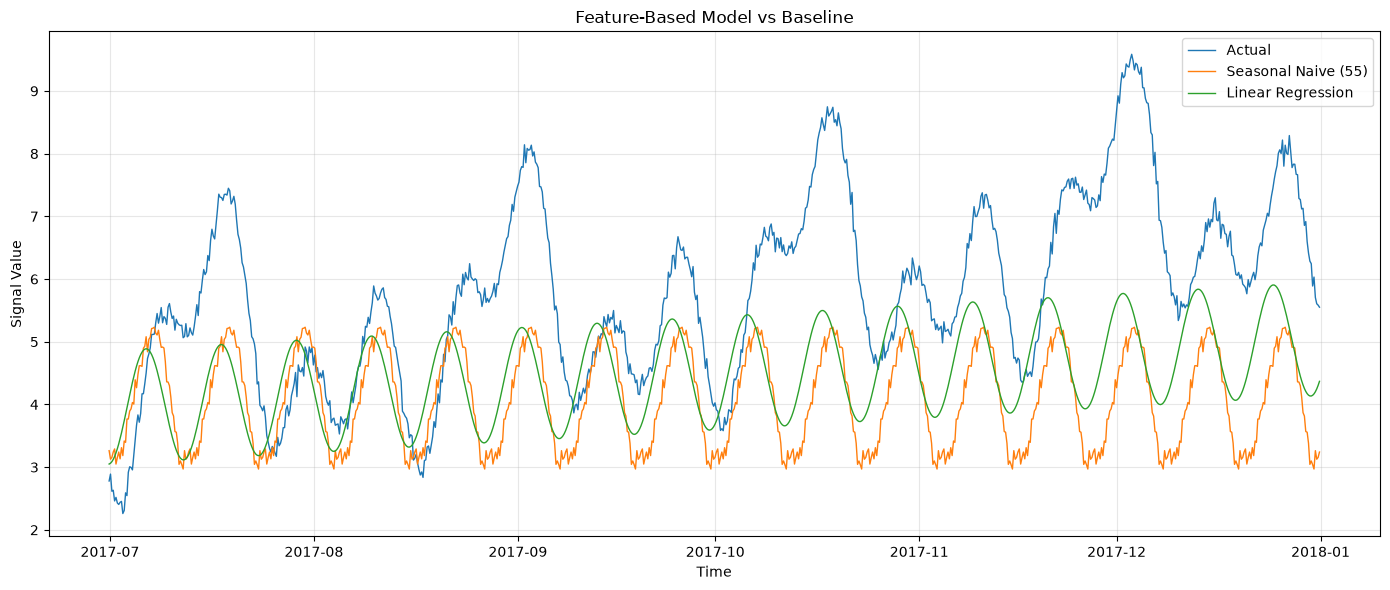

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation["datetime"],
    y_validation,
    label="Actual",
    linewidth=1
)

plt.plot(
    validation["datetime"],
    seasonal_forecast,
    label="Seasonal Naive (55)",
    linewidth=1
)

plt.plot(
    validation["datetime"],
    linear_forecast,
    label="Linear Regression",
    linewidth=1
)

plt.title("Feature-Based Model vs Baseline")
plt.xlabel("Time")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Seasonal Naive captures the repeating cycle, but its level stays almost fixed, so it misses the upward movement of the signal.
Linear Regression captures both the upward trend and the ~11.42-day periodic pattern, so it follows the overall behavior better.
However, it still underestimates the large peaks toward the end of the validation period. The actual signal reaches ~9–9.5, while the model peaks around ~5.5–5.8.

So our current conclusion is:

Trend + periodicity is a better representation than simply repeating the previous cycle, but our current linear model is too simple to capture the changing amplitude/large peaks of the signal.

## 8. Adding a Second Harmonic

The first linear regression model captures the overall trend and the dominant periodic cycle, but the forecast plot shows that the actual cycles are not perfectly sinusoidal.

A single sine/cosine pair represents a simple smooth cycle. To allow the model to represent more complex shapes within the same cycle, we add a second harmonic.

If

$$
\theta_t = \frac{2\pi t}{P}
$$

the first harmonic is:

$$
\sin(\theta_t), \qquad \cos(\theta_t)
$$

and the second harmonic is:

$$
\sin(2\theta_t), \qquad \cos(2\theta_t)
$$

The second harmonic does not introduce a new independent long-term period. Instead, it provides additional flexibility to describe the shape of the existing recurring pattern.

We will evaluate whether these additional features improve the validation error compared with the previous model.

In [16]:
# Create a copy of the existing feature data
feature_data_h2 = feature_data.copy()

# Existing cycle angle
cycle_angle = (
    2 * np.pi * feature_data_h2["time_index"]
    / DOMINANT_PERIOD_STEPS
)

# Second harmonic
feature_data_h2["sin_cycle_2"] = np.sin(2 * cycle_angle)
feature_data_h2["cos_cycle_2"] = np.cos(2 * cycle_angle)

display(feature_data_h2.head())

,datetime,value,time_index,sin_cycle,cos_cycle,sin_cycle_2,cos_cycle_2
0,2016-01-01 00:00:00,0.140965,0,0.000000,1.000000,0.000000,1.000000
1,2016-01-01 05:00:00,-0.014609,1,0.114356,0.993440,0.227211,0.973846
2,2016-01-01 10:00:00,0.325199,2,0.227211,0.973846,0.442537,0.896750
3,2016-01-01 15:00:00,0.504311,3,0.337085,0.941474,0.634714,0.772747
4,2016-01-01 20:00:00,0.545418,4,0.442537,0.896750,0.793690,0.608322


In [17]:
feature_columns_h2 = [
    "time_index",
    "sin_cycle",
    "cos_cycle",
    "sin_cycle_2",
    "cos_cycle_2"
]

X = feature_data_h2[feature_columns_h2]
y = feature_data_h2["value"]

train_mask = feature_data_h2["datetime"] < validation_start
validation_mask = feature_data_h2["datetime"] >= validation_start

X_train = X.loc[train_mask]
X_validation = X.loc[validation_mask]

y_train = y.loc[train_mask]
y_validation = y.loc[validation_mask]


# Train model
linear_model_h2 = LinearRegression()

linear_model_h2.fit(
    X_train,
    y_train
)


# Validation forecast
linear_forecast_h2 = linear_model_h2.predict(
    X_validation
)


# Evaluation
linear_h2_mae = mean_absolute_error(
    y_validation,
    linear_forecast_h2
)

linear_h2_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        linear_forecast_h2
    )
)

print("Linear Regression + 2nd Harmonic")
print("MAE :", round(linear_h2_mae, 4))
print("RMSE:", round(linear_h2_rmse, 4))

Linear Regression + 2nd Harmonic
MAE : 1.5121
RMSE: 1.8422


## 9. Allowing the Periodic Amplitude to Change

The previous model assumes that the periodic component has approximately constant amplitude throughout the forecasting period.

However, the validation plot suggests that the size of the signal's oscillations changes over time, with some later peaks substantially larger than earlier peaks.

To test this, we introduce interaction features between the time index and the periodic components:

$$
t\sin(\theta_t)
$$

and

$$
t\cos(\theta_t)
$$

where

$$
\theta_t = \frac{2\pi t}{P}
$$

These features allow the amplitude of the periodic component to change systematically with time.

The model can therefore represent a structure closer to:

$$
\text{Signal}
=
\text{Trend}
+
\text{Time-varying periodic component}
$$

This is an experiment rather than an assumption. Its usefulness will be determined by validation performance.

In [18]:
feature_data_amp = feature_data.copy()

cycle_angle = (
    2 * np.pi * feature_data_amp["time_index"]
    / DOMINANT_PERIOD_STEPS
)

feature_data_amp["time_sin_cycle"] = (
    feature_data_amp["time_index"]
    * np.sin(cycle_angle)
)

feature_data_amp["time_cos_cycle"] = (
    feature_data_amp["time_index"]
    * np.cos(cycle_angle)
)

display(
    feature_data_amp[
        [
            "datetime",
            "value",
            "time_index",
            "sin_cycle",
            "cos_cycle",
            "time_sin_cycle",
            "time_cos_cycle"
        ]
    ].head()
)

,datetime,value,time_index,sin_cycle,cos_cycle,time_sin_cycle,time_cos_cycle
0,2016-01-01 00:00:00,0.140965,0,0.000000,1.000000,0.000000,0.000000
1,2016-01-01 05:00:00,-0.014609,1,0.114356,0.993440,0.114356,0.993440
2,2016-01-01 10:00:00,0.325199,2,0.227211,0.973846,0.454422,1.947691
3,2016-01-01 15:00:00,0.504311,3,0.337085,0.941474,1.011256,2.824422
4,2016-01-01 20:00:00,0.545418,4,0.442537,0.896750,1.770148,3.587001


In [19]:
feature_columns_amp = [
    "time_index",
    "sin_cycle",
    "cos_cycle",
    "time_sin_cycle",
    "time_cos_cycle"
]

X = feature_data_amp[feature_columns_amp]
y = feature_data_amp["value"]

train_mask = feature_data_amp["datetime"] < validation_start
validation_mask = feature_data_amp["datetime"] >= validation_start

X_train = X.loc[train_mask]
X_validation = X.loc[validation_mask]

y_train = y.loc[train_mask]
y_validation = y.loc[validation_mask]


linear_model_amp = LinearRegression()

linear_model_amp.fit(
    X_train,
    y_train
)

linear_forecast_amp = linear_model_amp.predict(
    X_validation
)


linear_amp_mae = mean_absolute_error(
    y_validation,
    linear_forecast_amp
)

linear_amp_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        linear_forecast_amp
    )
)

print("Linear Regression + Time-Varying Amplitude")
print("MAE :", round(linear_amp_mae, 4))
print("RMSE:", round(linear_amp_rmse, 4))

Linear Regression + Time-Varying Amplitude
MAE : 1.4045
RMSE: 1.7447


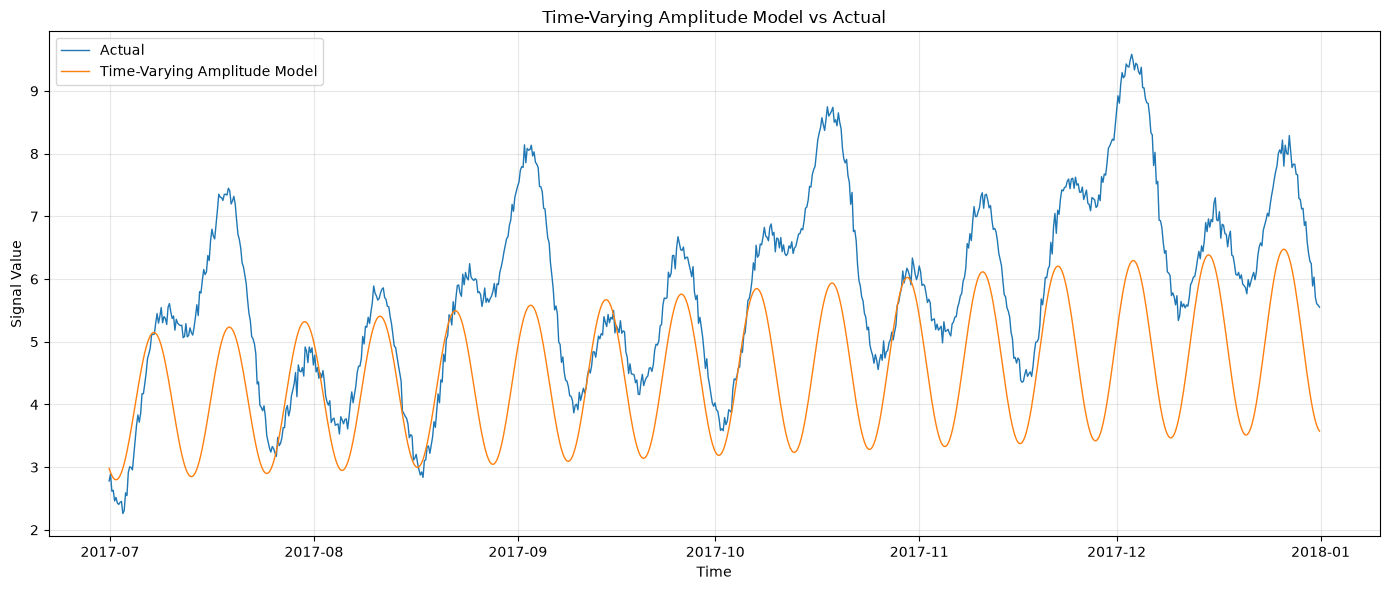

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation["datetime"],
    y_validation,
    label="Actual",
    linewidth=1
)

plt.plot(
    validation["datetime"],
    linear_forecast_amp,
    label="Time-Varying Amplitude Model",
    linewidth=1
)

plt.title("Time-Varying Amplitude Model vs Actual")
plt.xlabel("Time")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Time-Varying Amplitude Model — Visual Results

The model now follows the **overall upward movement** of the signal better than the previous models and produces a periodic pattern whose amplitude gradually increases over time.

The forecast still does not capture every short-term fluctuation or the largest peaks, but it captures the two main structures we identified during EDA:

- **Changing signal level over time**
- **Recurring ~11.42-day pattern with changing amplitude**

Combined with the validation metrics:

$$
MAE = 1.4045,\qquad RMSE = 1.7447
$$

this is currently our **best-performing model**.

The next step is to examine its **residuals (prediction errors)** and check whether any systematic structure remains unexplained.

## 10. Residual Analysis

A residual is the difference between the actual value and the model prediction:

$$
e_t = y_t - \hat{y}_t
$$

Residual analysis helps determine whether the model has captured the important structure of the signal.

If the residuals are mostly random and centered around zero, there may be little predictable structure left.

If the residuals show a trend, repeating pattern, or strong autocorrelation, this indicates that the current model is still missing some systematic behavior.

Therefore, we examine the residuals both visually and through autocorrelation.

In [21]:
# Calculate residuals
residuals = y_validation.to_numpy() - linear_forecast_amp

print("Residual mean:", round(residuals.mean(), 4))
print("Residual std :", round(residuals.std(), 4))
print("Residual MAE :", round(np.abs(residuals).mean(), 4))

Residual mean: 1.3144
Residual std : 1.1473
Residual MAE : 1.4045


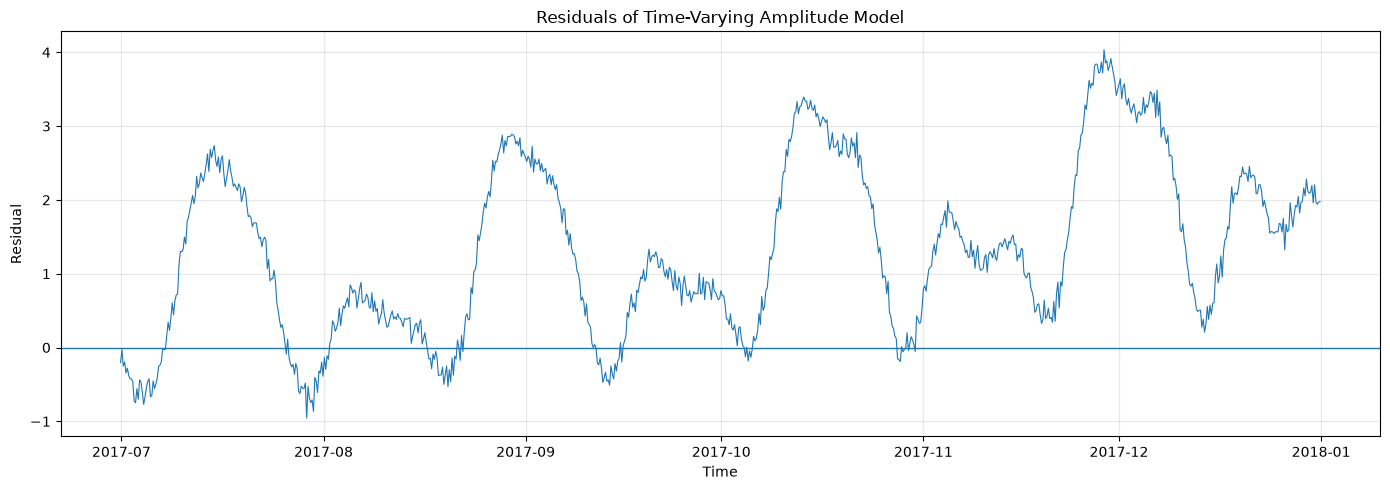

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(
    validation["datetime"],
    residuals,
    linewidth=0.8
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Residuals of Time-Varying Amplitude Model")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Residual Analysis  Results

The residual plot shows that the errors are not completely random.

The residuals are predominantly positive during the later validation period, indicating that the model increasingly underestimates the signal level.

A repeating oscillatory pattern is also visible in the residuals, suggesting that some predictable temporal structure remains unexplained by the current model.

Therefore, the current model is not yet sufficient for the final forecast. We next examine the residual autocorrelation to determine whether the remaining error contains a systematic periodic component.

## 11. Residual Autocorrelation

The residual plot showed a visible oscillatory pattern, suggesting that some temporal structure remains unexplained by the current model.

We therefore calculate the autocorrelation of the residuals.

If the residuals were approximately random, their autocorrelation would quickly approach zero.

Strong repeated peaks in the residual ACF would indicate that the model has not fully captured the recurring structure of the signal.

The analysis is performed over a 14-day window so that the previously identified dominant period of approximately 274 hours can be examined directly.

In [25]:
# Calculate residual ACF

def autocorrelation(values, max_lag):
    values = np.asarray(values, dtype=float)
    values = values - values.mean()

    denominator = np.dot(values, values)

    result = np.empty(max_lag + 1)
    result[0] = 1.0

    for lag in range(1, max_lag + 1):
        result[lag] = (
            np.dot(values[:-lag], values[lag:])
            / denominator
        )

    return result


MAX_RESIDUAL_LAG_HOURS = 14 * 24

max_residual_lag = int(
    MAX_RESIDUAL_LAG_HOURS / SAMPLING_HOURS
)

residual_acf = autocorrelation(
    residuals,
    max_residual_lag
)

residual_lags = np.arange(
    max_residual_lag + 1
)

residual_lag_hours = (
    residual_lags * SAMPLING_HOURS
)

residual_acf_df = pd.DataFrame({
    "lag_hours": residual_lag_hours,
    "autocorrelation": residual_acf
})

display(residual_acf_df.head())

,lag_hours,autocorrelation
0,0,1.000000
1,5,0.989807
2,10,0.984848
3,15,0.977387
4,20,0.967407


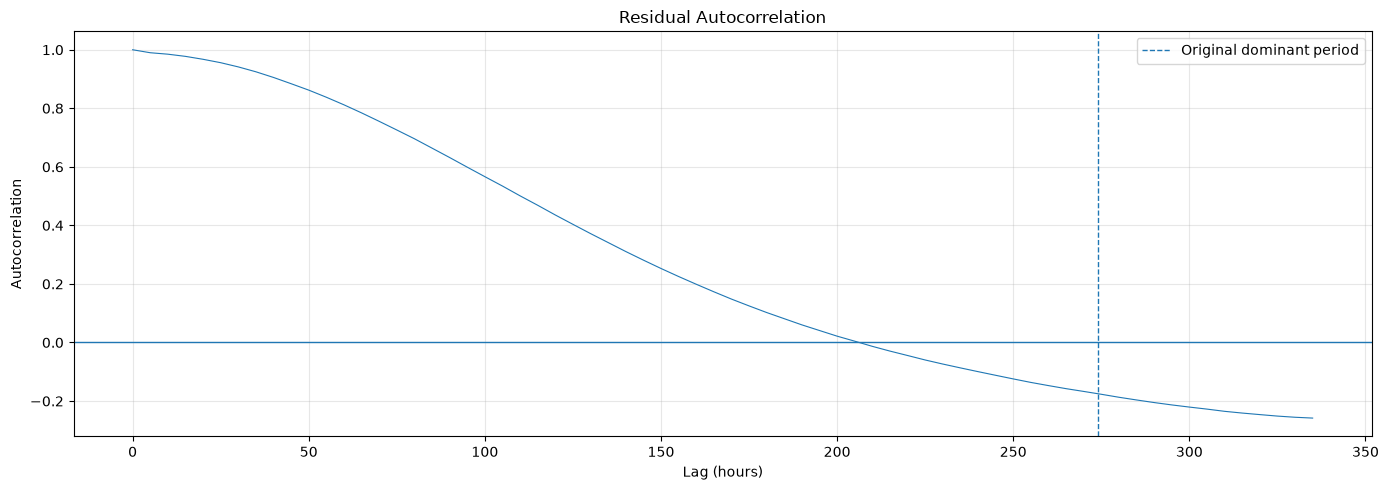

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(
    residual_acf_df["lag_hours"],
    residual_acf_df["autocorrelation"],
    linewidth=0.8
)

plt.axhline(
    0,
    linewidth=1
)

plt.axvline(
    DOMINANT_PERIOD_HOURS,
    linestyle="--",
    linewidth=1,
    label="Original dominant period"
)

plt.title("Residual Autocorrelation")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Residual Autocorrelation — Results

The residual autocorrelation decreases gradually from a high value toward zero and does not show a clear repeated peak around the previously identified 274-hour period.

This suggests that the current model has captured most of the dominant periodic structure identified during exploratory analysis.

However, the residuals remain strongly autocorrelated at shorter lags, indicating that some temporal structure is still unexplained.

Therefore, adding another periodic harmonic is not strongly motivated by the residual ACF. The next experiment will investigate whether recent signal information can improve the remaining forecast errors.

## 12. Lag-Based Features

The previous model used time and periodic features to describe the global structure of the signal.

The residual analysis showed that some temporal dependence remains. We therefore test whether the recent observed values contain additional predictive information.

Lag features provide the model with previous signal values:

$$
\text{lag}_k(t) = y_{t-k}
$$

For the 5-hour dataset, the selected lags represent different time scales:

- lag 1: previous 5 hours
- lag 2: previous 10 hours
- lag 11: approximately 2.3 days
- lag 55: approximately one dominant 11.42-day cycle

These features allow the model to use the actual recent behavior of the signal rather than relying only on the theoretical periodic pattern.

Because lag features depend on previous signal values, a long-horizon forecast must be generated recursively: predictions made at earlier steps become inputs for later predictions.

This experiment will determine whether recent signal information provides additional predictive value beyond the trend and periodic features.

In [27]:
LAGS = [1, 2, 11, 55]

lag_data = feature_data.copy()

for lag in LAGS:
    lag_data[f"lag_{lag}"] = lag_data["value"].shift(lag)

display(lag_data.head(60))

,datetime,value,time_index,sin_cycle,cos_cycle,lag_1,lag_2,lag_11,lag_55
0,2016-01-01 00:00:00,0.140965,0,0.000000,1.000000,NaN,NaN,NaN,NaN
1,2016-01-01 05:00:00,-0.014609,1,0.114356,0.993440,0.140965,NaN,NaN,NaN
2,2016-01-01 10:00:00,0.325199,2,0.227211,0.973846,-0.014609,0.140965,NaN,NaN
3,2016-01-01 15:00:00,0.504311,3,0.337085,0.941474,0.325199,-0.014609,NaN,NaN
4,2016-01-01 20:00:00,0.545418,4,0.442537,0.896750,0.504311,0.325199,NaN,NaN
5,2016-01-02 01:00:00,0.674843,5,0.542183,0.840261,0.545418,0.504311,NaN,NaN
6,2016-01-02 06:00:00,0.900984,6,0.634714,0.772747,0.674843,0.545418,NaN,NaN
7,2016-01-02 11:00:00,0.937778,7,0.718919,0.695094,0.900984,0.674843,NaN,NaN
8,2016-01-02 16:00:00,0.995823,8,0.793690,0.608322,0.937778,0.900984,NaN,NaN
9,2016-01-02 21:00:00,1.175420,9,0.858049,0.513568,0.995823,0.937778,NaN,NaN


## 13. Recursive Lag-Based Forecast

A lag-based model uses previous signal values to predict the next value.

The model is trained using the selected lag features:

$$
y_{t-1},\ y_{t-2},\ y_{t-11},\ y_{t-55}
$$

The model learns a relationship of the form:

$$
\hat{y}_t =
f(y_{t-1}, y_{t-2}, y_{t-11}, y_{t-55})
$$

For validation, future actual values cannot be used as lag inputs. Therefore, predictions are generated recursively.

The first prediction uses only historical training observations. After that prediction is made, it becomes part of the available history and is used when generating subsequent predictions.

This simulates how the model would behave when forecasting multiple steps into the future.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# --------------------------------------------------
# 1. Create lag features for training
# --------------------------------------------------

LAGS = [1, 2, 11, 55]

lag_data = df[["datetime", "value"]].copy()

for lag in LAGS:
    lag_data[f"lag_{lag}"] = lag_data["value"].shift(lag)


# Keep only training period
lag_train = lag_data[
    lag_data["datetime"] < validation_start
].copy()

lag_train = lag_train.dropna()


# --------------------------------------------------
# 2. Define training features and target
# --------------------------------------------------

lag_columns = [
    "lag_1",
    "lag_2",
    "lag_11",
    "lag_55"
]

X_train_lag = lag_train[lag_columns]
y_train_lag = lag_train["value"]


# --------------------------------------------------
# 3. Train lag-based model
# --------------------------------------------------

lag_model = LinearRegression()

lag_model.fit(
    X_train_lag,
    y_train_lag
)


# --------------------------------------------------
# 4. Recursive validation forecasting
# --------------------------------------------------

# Start with all historical training values
history = train["value"].tolist()

recursive_forecast = []

for _ in range(len(validation)):

    lag_features = np.array([
        history[-1],    # lag 1
        history[-2],    # lag 2
        history[-11],   # lag 11
        history[-55]    # lag 55
    ]).reshape(1, -1)

    prediction = lag_model.predict(
        lag_features
    )[0]

    recursive_forecast.append(prediction)

    # Important:
    # the prediction becomes part of the history
    history.append(prediction)


# --------------------------------------------------
# 5. Evaluate
# --------------------------------------------------

actual = validation["value"].to_numpy()

lag_mae = mean_absolute_error(
    actual,
    recursive_forecast
)

lag_rmse = np.sqrt(
    mean_squared_error(
        actual,
        recursive_forecast
    )
)

print("Recursive Lag-Based Linear Regression")
print("MAE :", round(lag_mae, 4))
print("RMSE:", round(lag_rmse, 4))

Recursive Lag-Based Linear Regression
MAE : 3.5273
RMSE: 3.8115


d:\Mlprojects\signal-forecasting-assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Mlprojects\signal-forecasting-assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Mlprojects\signal-forecasting-assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Mlprojects\signal-forecasting-assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Mlprojects\signal-forecasting-assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X doe

## 12. Testing a Nonlinear Trend

The current model represents the changing signal level using a linear time trend.

However, the validation plot suggests that the overall level may not change at a constant rate. To test this possibility, we add a squared time feature:

$$
t^2
$$

This allows the model to represent a curved trend rather than being restricted to a straight line.

The periodic features and time-varying amplitude features are kept unchanged. Therefore, this experiment isolates the effect of allowing the long-term trend to be nonlinear.

The new model will be evaluated against the current best model using the same chronological validation period and the same MAE and RMSE metrics.

In [29]:
# Create normalized time
feature_data_nonlinear = feature_data_amp.copy()

feature_data_nonlinear["time_normalized"] = (
    feature_data_nonlinear["time_index"]
    / feature_data_nonlinear["time_index"].max()
)

feature_data_nonlinear["time_squared"] = (
    feature_data_nonlinear["time_normalized"] ** 2
)


display(
    feature_data_nonlinear[
        [
            "datetime",
            "value",
            "time_index",
            "time_normalized",
            "time_squared"
        ]
    ].head()
)

,datetime,value,time_index,time_normalized,time_squared
0,2016-01-01 00:00:00,0.140965,0,0.000000,0.000000e+00
1,2016-01-01 05:00:00,-0.014609,1,0.000285,8.126075e-08
2,2016-01-01 10:00:00,0.325199,2,0.000570,3.250430e-07
3,2016-01-01 15:00:00,0.504311,3,0.000855,7.313468e-07
4,2016-01-01 20:00:00,0.545418,4,0.001140,1.300172e-06


In [30]:
feature_columns_nonlinear = [
    "time_normalized",
    "time_squared",
    "sin_cycle",
    "cos_cycle",
    "time_sin_cycle",
    "time_cos_cycle"
]

X = feature_data_nonlinear[feature_columns_nonlinear]
y = feature_data_nonlinear["value"]

train_mask = (
    feature_data_nonlinear["datetime"] < validation_start
)

validation_mask = (
    feature_data_nonlinear["datetime"] >= validation_start
)

X_train = X.loc[train_mask]
X_validation = X.loc[validation_mask]

y_train = y.loc[train_mask]
y_validation = y.loc[validation_mask]


# Train model
linear_model_nonlinear = LinearRegression()

linear_model_nonlinear.fit(
    X_train,
    y_train
)


# Validation forecast
linear_forecast_nonlinear = (
    linear_model_nonlinear.predict(X_validation)
)


# Evaluation
nonlinear_mae = mean_absolute_error(
    y_validation,
    linear_forecast_nonlinear
)

nonlinear_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        linear_forecast_nonlinear
    )
)


print("Linear Regression + Nonlinear Trend")
print("MAE :", round(nonlinear_mae, 4))
print("RMSE:", round(nonlinear_rmse, 4))

Linear Regression + Nonlinear Trend
MAE : 0.8703
RMSE: 1.0974


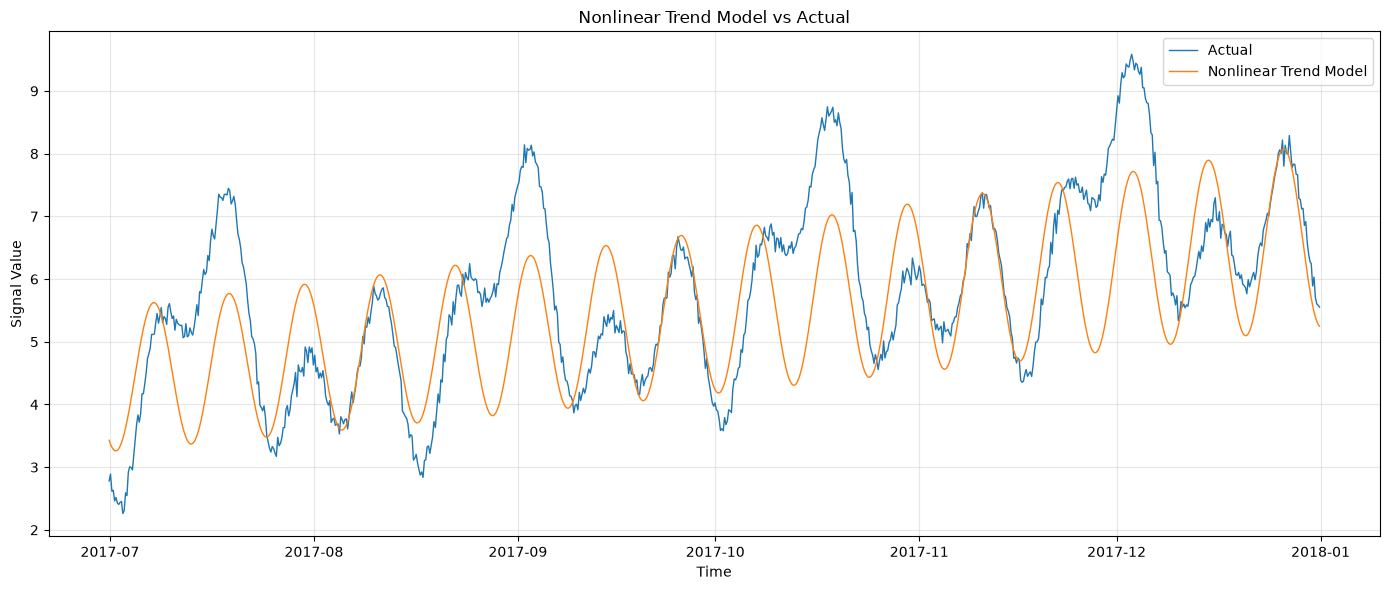

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation["datetime"],
    y_validation,
    label="Actual",
    linewidth=1
)

plt.plot(
    validation["datetime"],
    linear_forecast_nonlinear,
    label="Nonlinear Trend Model",
    linewidth=1
)

plt.title("Nonlinear Trend Model vs Actual")
plt.xlabel("Time")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
feature_data_amp_nonlinear = feature_data_nonlinear.copy()

feature_data_amp_nonlinear["time_squared_sin_cycle"] = (
    feature_data_amp_nonlinear["time_squared"]
    * feature_data_amp_nonlinear["sin_cycle"]
)

feature_data_amp_nonlinear["time_squared_cos_cycle"] = (
    feature_data_amp_nonlinear["time_squared"]
    * feature_data_amp_nonlinear["cos_cycle"]
)

In [33]:
feature_columns_amp_nonlinear = [
    "time_normalized",
    "time_squared",
    "sin_cycle",
    "cos_cycle",
    "time_sin_cycle",
    "time_cos_cycle",
    "time_squared_sin_cycle",
    "time_squared_cos_cycle"
]

In [34]:
X = feature_data_amp_nonlinear[feature_columns_amp_nonlinear]
y = feature_data_amp_nonlinear["value"]

train_mask = feature_data_amp_nonlinear["datetime"] < validation_start
validation_mask = feature_data_amp_nonlinear["datetime"] >= validation_start

X_train = X.loc[train_mask]
X_validation = X.loc[validation_mask]

y_train = y.loc[train_mask]
y_validation = y.loc[validation_mask]

amplitude_nonlinear_model = LinearRegression()
amplitude_nonlinear_model.fit(X_train, y_train)

amplitude_nonlinear_forecast = (
    amplitude_nonlinear_model.predict(X_validation)
)

amplitude_nonlinear_mae = mean_absolute_error(
    y_validation,
    amplitude_nonlinear_forecast
)

amplitude_nonlinear_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        amplitude_nonlinear_forecast
    )
)

print("Nonlinear Amplitude Model")
print("MAE :", round(amplitude_nonlinear_mae, 4))
print("RMSE:", round(amplitude_nonlinear_rmse, 4))

Nonlinear Amplitude Model
MAE : 0.8155
RMSE: 1.0573


In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Current Best: Nonlinear Trend + Linear Amplitude",
        "Nonlinear Trend + Nonlinear Amplitude"
    ],
    "MAE": [
        nonlinear_mae,
        amplitude_nonlinear_mae
    ],
    "RMSE": [
        nonlinear_rmse,
        amplitude_nonlinear_rmse
    ]
}).round(4)

display(comparison)

,Model,MAE,RMSE
0,Current Best: Nonlinear Trend + Linear Amplitude,0.8703,1.0974
1,Nonlinear Trend + Nonlinear Amplitude,0.8155,1.0573


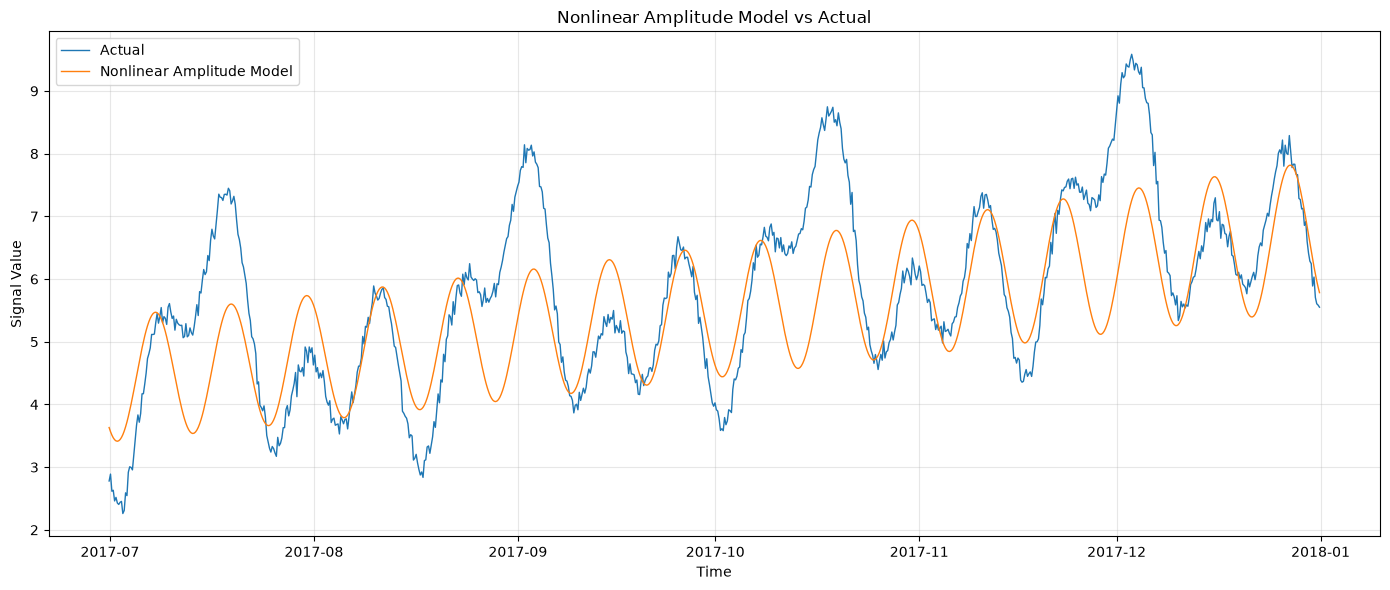

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation["datetime"],
    y_validation,
    label="Actual",
    linewidth=1
)

plt.plot(
    validation["datetime"],
    amplitude_nonlinear_forecast,
    label="Nonlinear Amplitude Model",
    linewidth=1
)

plt.title("Nonlinear Amplitude Model vs Actual")
plt.xlabel("Time")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Model Comparison

The feature-engineering stage has identified a useful set of eight features representing the signal's nonlinear trend, dominant periodicity, and changing periodic amplitude.

We now keep this feature set **fixed** and compare different regression models.

The purpose of this experiment is to determine whether a more flexible machine-learning model can improve upon the current Linear Regression benchmark.

All models will use:

- the same eight features,
- the same chronological training-validation split,
- the same six-month validation period,
- and the same evaluation metrics: MAE and RMSE.

The current best Linear Regression model provides the benchmark:

$$
MAE = 0.8155,\qquad RMSE = 1.0573
$$

We will first compare Linear Regression with tree-based models to determine whether additional nonlinear modeling capacity provides a meaningful improvement.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

feature_columns = [
    "time_normalized",
    "time_squared",
    "sin_cycle",
    "cos_cycle",
    "time_sin_cycle",
    "time_cos_cycle",
    "time_squared_sin_cycle",
    "time_squared_cos_cycle"
]

X = feature_data_amp_nonlinear[feature_columns]
y = feature_data_amp_nonlinear["value"]

train_mask = feature_data_amp_nonlinear["datetime"] < validation_start
validation_mask = feature_data_amp_nonlinear["datetime"] >= validation_start

X_train = X.loc[train_mask]
X_validation = X.loc[validation_mask]

y_train = y.loc[train_mask]
y_validation = y.loc[validation_mask]

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)

Training shape: (2625, 8)
Validation shape: (884, 8)


In [38]:
def evaluate_model(model, X_train, y_train, X_validation, y_validation):
    model.fit(X_train, y_train)
    predictions = model.predict(X_validation)

    mae = mean_absolute_error(y_validation, predictions)
    rmse = np.sqrt(mean_squared_error(y_validation, predictions))

    return model, predictions, mae, rmse

In [39]:
linear_model = LinearRegression()

linear_model, linear_predictions, linear_mae, linear_rmse = evaluate_model(
    linear_model,
    X_train,
    y_train,
    X_validation,
    y_validation
)

print("Linear Regression")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))

Linear Regression
MAE : 0.8155
RMSE: 1.0573


In [40]:
random_forest = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

random_forest, rf_predictions, rf_mae, rf_rmse = evaluate_model(
    random_forest,
    X_train,
    y_train,
    X_validation,
    y_validation
)

print("Random Forest")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))

Random Forest
MAE : 1.8491
RMSE: 2.2138


In [41]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

gradient_boosting, gb_predictions, gb_mae, gb_rmse = evaluate_model(
    gradient_boosting,
    X_train,
    y_train,
    X_validation,
    y_validation
)

print("Gradient Boosting")
print("MAE :", round(gb_mae, 4))
print("RMSE:", round(gb_rmse, 4))

Gradient Boosting
MAE : 1.7832
RMSE: 2.1456


In [42]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ]
}).sort_values("MAE").round(4)

display(model_comparison)

,Model,MAE,RMSE
0,Linear Regression,0.8155,1.0573
2,Gradient Boosting,1.7832,2.1456
1,Random Forest,1.8491,2.2138


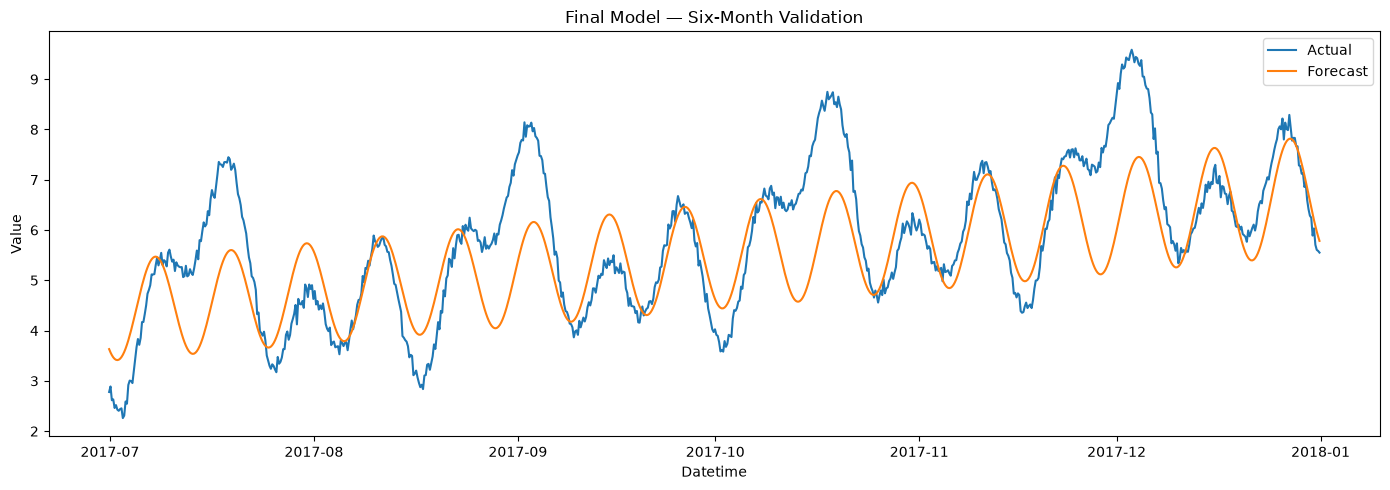

In [50]:
final_validation_model = LinearRegression()

final_validation_model.fit(
    X_train,
    y_train
)

validation_predictions = final_validation_model.predict(
    X_validation
)

plt.figure(figsize=(14, 5))

plt.plot(
    validation["datetime"],
    validation["value"],
    label="Actual"
)

plt.plot(
    validation["datetime"],
    validation_predictions,
    label="Forecast"
)

plt.xlabel("Datetime")
plt.ylabel("Value")
plt.title("Final Model — Six-Month Validation")
plt.legend()
plt.tight_layout()
plt.show()

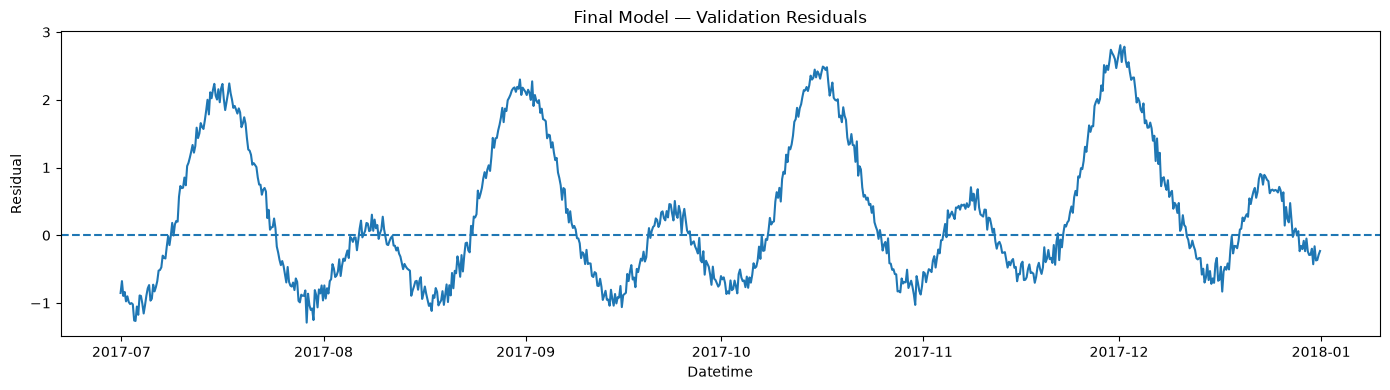

In [51]:
validation_residuals = (
    y_validation.to_numpy() - validation_predictions
)

plt.figure(figsize=(14, 4))

plt.plot(
    validation["datetime"],
    validation_residuals
)

plt.axhline(0, linestyle="--")

plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.title("Final Model — Validation Residuals")
plt.tight_layout()
plt.show()